# Analisis Efek Operasi Penjumlahan dan Perbesaran Citra Digital

**Manfaat:**  
Memahami bagaimana penggabungan dan pembesaran citra mempengaruhi kualitas visual, termasuk perubahan warna, kontras, dan detail.

**Dataset:**  
efek-operasi-penjumlahan-dan-pembesaran-citra
(Dataset berisi dua citra dari **satu gambar yang sama**, namun dengan perbedaan pencahayaan: versi gelap dan versi terang.)

**Metode:**  
1. **Penyiapan Citra:**  
   - Mengambil satu gambar asli, lalu membuat versi **lebih gelap** dan **lebih terang**.  
   - Menyimpan kedua citra tersebut dalam dataset.
2. **Operasi Penjumlahan:**  
   - Menggabungkan dua citra secara pixel-by-pixel untuk melihat efek warna dan kontras.
3. **Operasi Perbesaran:**  
   - Melakukan scaling (zoom) terhadap hasil penggabungan citra.
4. **Analisis Kuantitatif:**  
   - **Rata-rata warna (R, G, B)** → melihat pergeseran tone.  
   - **Kontras** (σ luminance) → mengukur seberapa berbeda terang-gelapnya.  
   - **Detail** (Laplacian variance) → mengukur ketajaman gambar.

**Tujuan:**  
Mengetahui sejauh mana operasi penjumlahan dan perbesaran mempengaruhi kualitas visual citra digital.

# Import Library

In [1]:
# Library utama untuk citra
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob, os

# Path dataset dan output
DATA_DIR = "/kaggle/input/efek-operasi-penjumlahan-dan-pembesaran-citra"   # ganti dengan nama dataset di Kaggle
OUT_DIR = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

Tujuan :
- Mengimpor library yang dibutuhkan (cv2, numpy, matplotlib, dll).
- Menentukan folder dataset (DATA_DIR) dan folder output (OUT_DIR).
- Membuat folder output untuk menyimpan hasil olahan gambar.

# Fungsi untuk menampilkan citra dan untuk analisis statistik dasar citra

In [2]:
# Fungsi untuk menampilkan citra
def show(img, title="Image"):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

# Fungsi untuk analisis statistik dasar citra
def describe(name, img):
    mean_val = img.mean(axis=(0,1))
    std_val  = img.std(axis=(0,1))
    print(f"{name} - Mean RGB: {mean_val}, Std RGB: {std_val}")
    return mean_val, std_val

Tujuan :
- Membuat fungsi show() untuk mempermudah penampilan gambar.
- Membuat fungsi describe() untuk menghitung statistik mean & standar deviasi setiap channel RGB pada citra.

# Memuat Dua Gambar Asli

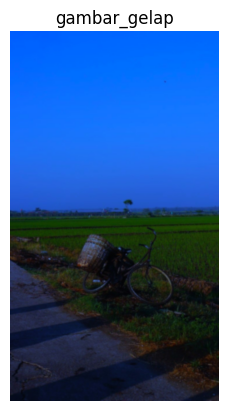

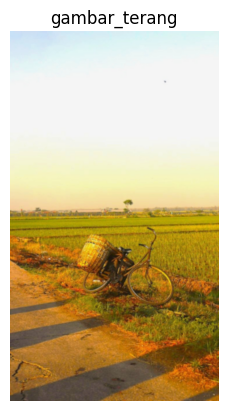

In [3]:
# Ambil semua file gambar di dataset
candidates = []
for ext in ("*.png", "*.jpg", "*.jpeg", "*.bmp"):
    candidates += glob.glob(os.path.join(DATA_DIR, ext))

if len(candidates) < 2:
    raise ValueError("Dataset membutuhkan minimal 2 gambar dengan pencahayaan berbeda!")

# Ambil 2 gambar pertama
img_dark   = cv2.imread(candidates[0])
img_bright = cv2.imread(candidates[1])

# Tampilkan
show(img_dark, "gambar_gelap")
show(img_bright, "gambar_terang")

Tujuan :
- Mengambil minimal 2 gambar dari dataset (dengan pencahayaan berbeda).
- Mengasumsikan candidates[0] adalah gambar gelap dan candidates[1] adalah gambar terang.
- Menampilkan kedua gambar untuk verifikasi.

# Operasi Penjumlahan & Perbesaran

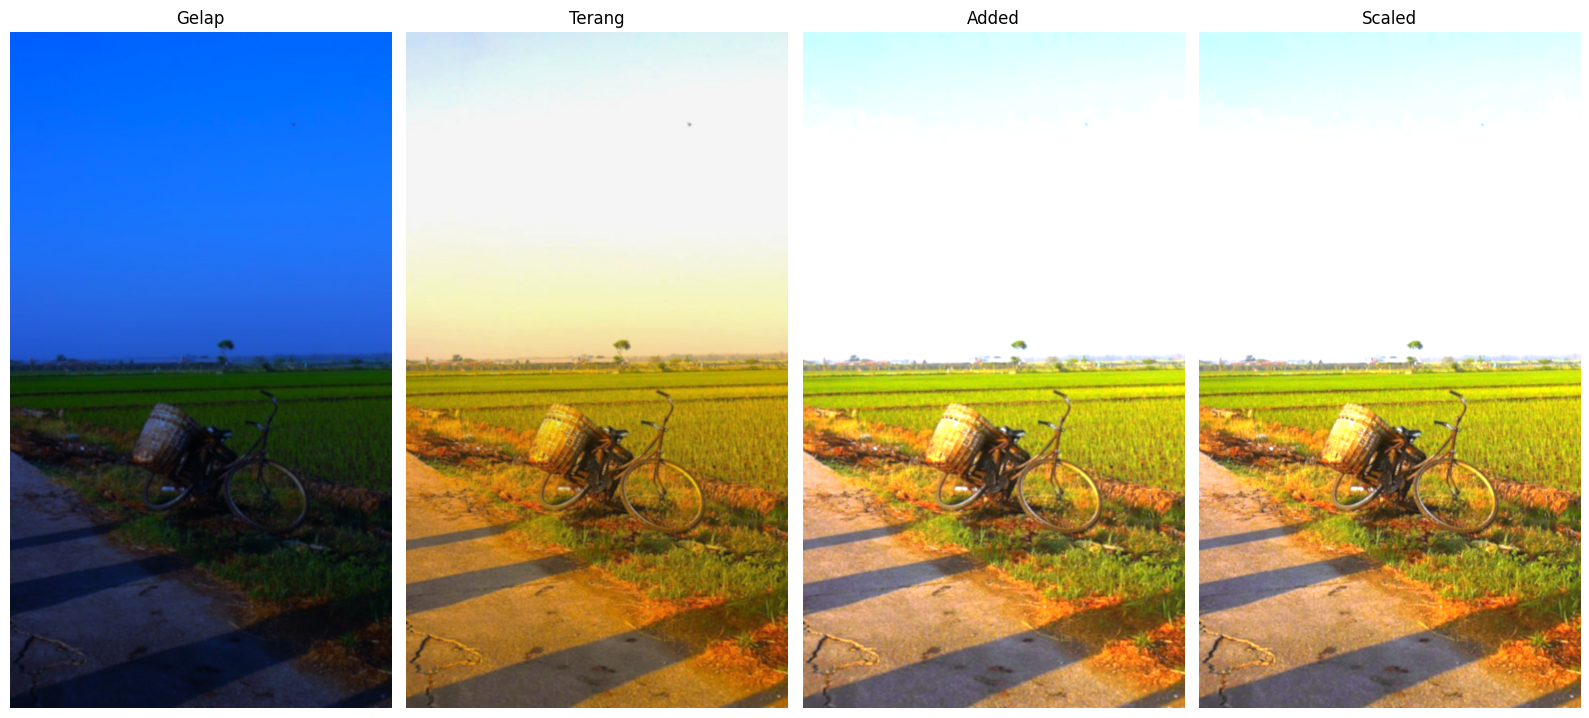

In [4]:
# Penjumlahan pixel-by-pixel
added = cv2.add(img_dark, img_bright)

# Perbesaran 30.0x
scaled = cv2.resize(added, None, fx=30.0, fy=30.0, interpolation=cv2.INTER_CUBIC)

# Simpan hasil
cv2.imwrite(os.path.join(OUT_DIR, "01_dark.png"), img_dark)
cv2.imwrite(os.path.join(OUT_DIR, "02_bright.png"), img_bright)
cv2.imwrite(os.path.join(OUT_DIR, "03_added.png"), added)
cv2.imwrite(os.path.join(OUT_DIR, "04_scaled.png"), scaled)

# Tampilkan semua tahap
titles = ["Gelap", "Terang", "Added", "Scaled"]
images = [img_dark, img_bright, added, scaled]

plt.figure(figsize=(16,9))
for i, (im, t) in enumerate(zip(images, titles), 1):
    plt.subplot(1,4,i)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(t)
    plt.axis("off")
plt.tight_layout()
plt.show()

Tujuan Cell 4:
- Menjumlahkan dua gambar untuk menghasilkan citra gabungan yang lebih terang.
- Memperbesar hasil penjumlahan dengan faktor 30.0 menggunakan interpolasi bicubic.
- Menyimpan semua hasil di /kaggle/working.
- Menampilkan keempat tahap dalam satu figure untuk perbandingan.

# Analisis Kuantitatif & Interpretasi

In [5]:
print("=== ANALISIS KUANTITATIF ===")
base_dark   = describe("Gelap", img_dark)
base_bright = describe("Terang", img_bright)
_           = describe("Added", added)
_           = describe("Scaled", scaled)

print("\n=== INTERPRETASI RINGKAS ===")
print("- Gambar gelap memiliki nilai rata-rata RGB rendah, menunjukkan tingkat kecerahan rendah.")
print("- Gambar terang memiliki nilai mean RGB lebih tinggi, menandakan intensitas cahaya lebih kuat.")
print("- Hasil penjumlahan meningkatkan kecerahan, tetapi bisa kehilangan detail di area highlight.")
print("- Perbesaran memperbesar citra tanpa menambah detail, cenderung menghaluskan tekstur.")

=== ANALISIS KUANTITATIF ===
Gelap - Mean RGB: [135.15512141  69.53777052  22.65666227], Std RGB: [107.5693966   39.59689165  14.03797832]
Terang - Mean RGB: [123.4451859  172.3192023  193.31799472], Std RGB: [101.78908437  70.94804978  55.26111561]
Added - Mean RGB: [155.02161639 196.00134392 209.40412916], Std RGB: [101.59631051  66.25178719  54.00558524]
Scaled - Mean RGB: [155.02068317 195.99983454 209.39872371], Std RGB: [101.60279934  66.26832002  54.02489625]

=== INTERPRETASI RINGKAS ===
- Gambar gelap memiliki nilai rata-rata RGB rendah, menunjukkan tingkat kecerahan rendah.
- Gambar terang memiliki nilai mean RGB lebih tinggi, menandakan intensitas cahaya lebih kuat.
- Hasil penjumlahan meningkatkan kecerahan, tetapi bisa kehilangan detail di area highlight.
- Perbesaran memperbesar citra tanpa menambah detail, cenderung menghaluskan tekstur.


Tujuan:
- Menghitung nilai mean & standar deviasi RGB pada setiap tahap.
- Memberikan interpretasi singkat terkait perubahan kecerahan dan kualitas gambar.
- Menjelaskan efek penjumlahan dan perbesaran terhadap citra.